# Dataset: ISOT Fake News Dataset

# Imports

In [1]:
# For loading data
import kagglehub
import numpy as np
import pandas as pd
import os

# Preprocessing
import nltk
import regex as re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# EDA
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.sentiment.vader import SentimentIntensityAnalyzer



# Intro

This NB focuses on cleaning up the dataset we have chosen for this part of the project. The data can be acquired in kaggle thorugh this [link](https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets/data). The real news were collected from Reuters.com (a news website) while the fake news articles were collected from other sources that were checked by Politifact (fact checking website). 

The true and false articles are in two seperate files.

Most of the news are in relation to politics.


# Preprocessing

Given that this dataset was quite large we were not able to insert it in the GitHub repo. Hence, we load it using kagglehub.

In [2]:
# Download latest version
path = kagglehub.dataset_download("emineyetm/fake-news-detection-datasets")
dir_data = os.path.join(path, "News _dataset")

# Read df           
df_true = pd.read_csv(os.path.join(dir_data, "True.csv")) 
df_false = pd.read_csv(os.path.join(dir_data, "Fake.csv"))
print(f"True DF size: {df_true.shape}")
print(f"False DF size: {df_false.shape}")

# Assign label
df_false["label"] = 0
df_true["label"] = 1

True DF size: (21417, 4)
False DF size: (23481, 4)


Now we check for duplicates in the text since this is the only feature we will be using.

In [3]:
df_false.drop_duplicates(subset=['text'], inplace=True)
df_true.drop_duplicates(subset=['text'], inplace=True)

We merge the two datasets and double check if there are duplicates.

In [4]:
df_reliable = pd.concat([df_true, df_false], ignore_index = True)
print(f"Shape of df_reliable: {df_reliable.shape}")


Shape of df_reliable: (38647, 5)


In [5]:
# Filtering Text Length
df_reliable = df_reliable[df_reliable["text"].str.split().str.len() <= 5000]
print(f"New shape after length filtering: {df_reliable.shape}")

New shape after length filtering: (38633, 5)


In [6]:
print(df_reliable.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [7]:
print(df_reliable["label"].value_counts())

label
1    21191
0    17442
Name: count, dtype: int64


Since we have done most of the heavy preprocessing (i.e. removing duplicates and length > 5000 words) one can observe that there is an inbalance between the number of fake articles and real articles we will randomly sameple 17442 observations from the true pile. This indicates that the false articles were most likely longer due that at the beginning of the notebook there were most false articles than true articles.

In [8]:
df_true_pre = df_reliable[df_reliable["label"] == 1]
df_false_pre = df_reliable[df_reliable["label"] == 0]

df_true_new = df_true_pre.sample(n = 17442, random_state = 42)

df_reliable = pd.concat([df_true_new, df_false_pre], ignore_index = True)

In [9]:
# Sanity check of balance
print(df_reliable["label"].value_counts())

label
1    17442
0    17442
Name: count, dtype: int64


Have to standadize text and remove stopwords

In [10]:
str_cols = ["title", "text", "subject"]
for col in str_cols:
    df_reliable[col] = df_reliable[col].str.lower()

# Removes punctuation from acronyms
df_reliable["text_clean"] = df_reliable["text"].str.replace(r"(?<=[a-z])\.|(?=[a-z])\.", "", regex = True) 
df_reliable["title_clean"] = df_reliable["title"].str.replace(r"(?<=[a-z])\.|(?=[a-z])\.", "", regex = True)

# Rest of the punctuation removed
df_reliable["text_clean"] = df_reliable["text_clean"].str.replace(r"[^\w\s]", " ", regex = True) 
df_reliable["title_clean"] = df_reliable["title_clean"].str.replace(r"[^\w\s]", " ", regex = True) 

In [11]:
# Dealing with stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stop_words.add("reuters")

keep_w = {"not", "no", "never", "us", "usa"}
rem_w = {"via", "say", "says", "said", "getty", "image", "images", "https", "year", "week", "last", "would", "also"}

stop_w = stop_words - keep_w | rem_w

def rem_stopw(text):
    words = text.split()
    filt_w = [word for word in words if word not in stop_w]
    return " ".join(filt_w)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
df_reliable["text_clean"] = df_reliable["text_clean"].apply(rem_stopw)
df_reliable["title_clean"] = df_reliable["title_clean"].apply(rem_stopw)

In [13]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lem_w = []

    for w in words:
        if w == "us":
            lem_w.append(w)
        else:
            root_w = lemmatizer.lemmatize(w)
            lem_w.append(root_w)
    return " ".join(lem_w)

In [14]:
df_reliable["text_clean"] = df_reliable["text_clean"].apply(lemmatize_text)
df_reliable["title_clean"] = df_reliable["title_clean"].apply(lemmatize_text)

In [15]:
df_reliable.columns

Index(['title', 'text', 'subject', 'date', 'label', 'text_clean',
       'title_clean'],
      dtype='object')

Cleans all possible empyty rows due to preprocessing

In [16]:
df_reliable = df_reliable.replace("", np.nan).dropna(subset = ["text_clean"])

In [17]:
df_clean = df_reliable.drop(["title", "subject", "date", "text", "title_clean"], axis = 1)

In [18]:
print(f"DF size: {df_reliable.shape}")

DF size: (34880, 7)


In [19]:
df_clean.to_csv("DF_final.csv", index = False)

# EDA

Since we are onyl going to use the clean text I have tokenized the text and title in order to plot the most common n grams.

In [20]:
df_reliable["title_tok"] = df_reliable["title_clean"].apply(word_tokenize)
df_reliable["text_tok"] = df_reliable["text_clean"].apply(word_tokenize)

This section is focused on exploring the clean preprocessed data which includes other features such as the title of the articles. In the following block we plot the n ngrams to observe the most common word combinations in the articles whether its real or fake.

In [21]:
# Showcases the frequency of n grams (x words combo)
def plot_n_grams(data, n, txt, ax):
    grams = []
    top = 10
    
    for doc in data:
        for i in range(len(doc) - n + 1):
            gram = tuple(doc[i: i+n])
            grams.append(gram)

    # displays top 10 n_grams
    gram_counts = Counter(grams).most_common(top)

    words =[]
    counts = []

    for gram, count in gram_counts:
        words.append(" ".join(gram))
        counts.append(count)

    sns.barplot(x = counts, y = words, color = "blue", ax=ax, legend = False)
    ax.set_title(f"Top {top} {n}-grams in the {txt}")

In [22]:
final_false = df_reliable[df_reliable["label"] == 0].copy()
final_true = df_reliable[df_reliable["label"] == 1].copy()

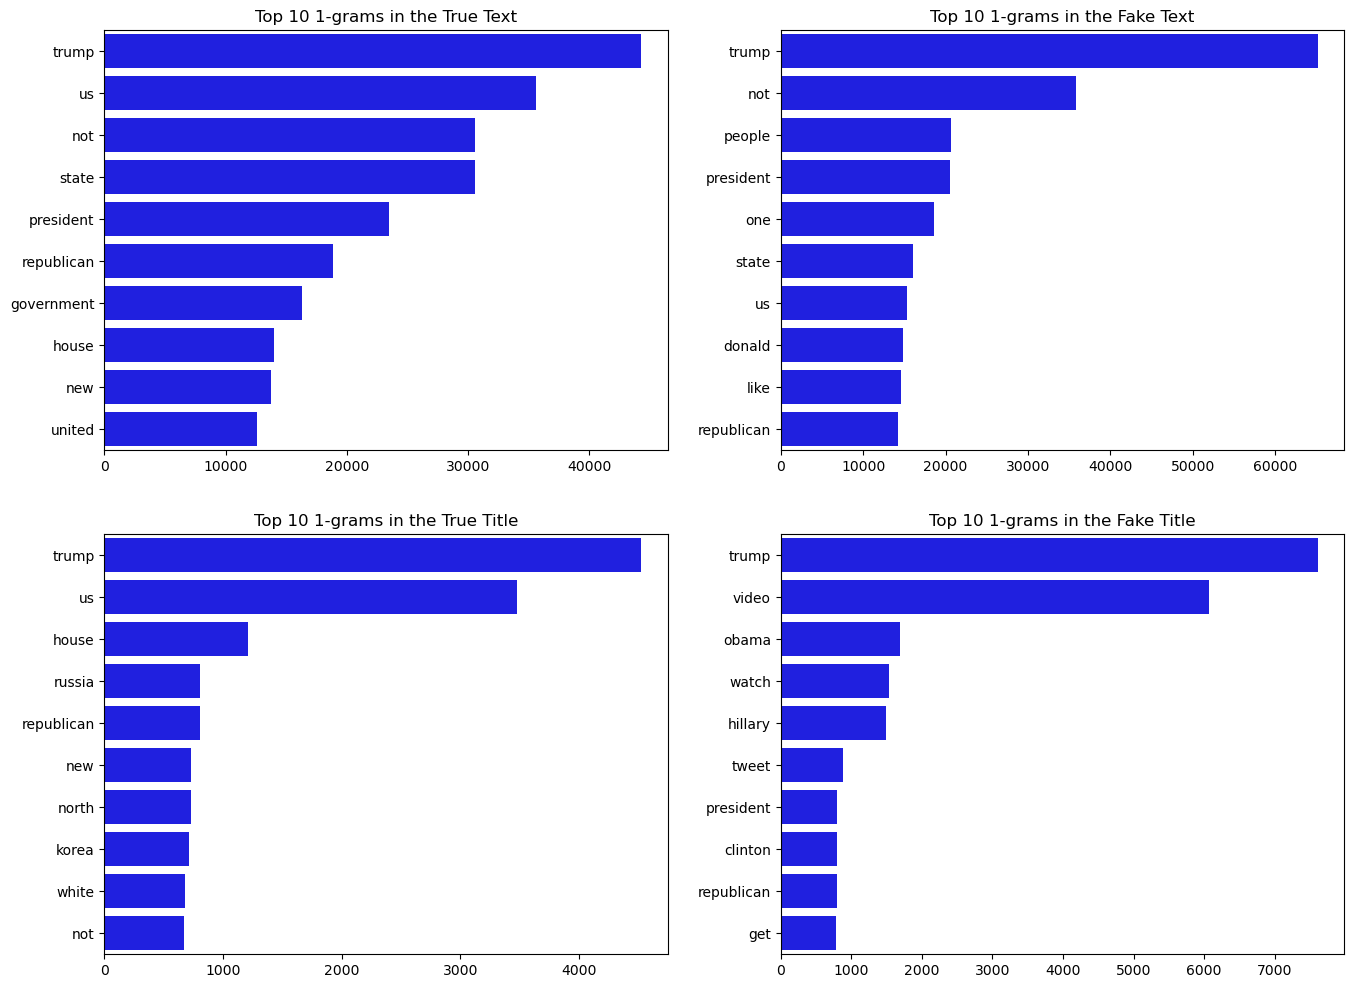

In [23]:
# 2x2 grid to plot text and title per type of article (real ad fake)

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

ax_flat = axes.flatten()

plot_n_grams(final_true["text_tok"], n = 1, txt = "True Text", ax = ax_flat[0])
plot_n_grams(final_false["text_tok"], n = 1, txt = "Fake Text", ax = ax_flat[1])

plot_n_grams(final_true["title_tok"], n = 1, txt = "True Title", ax = ax_flat[2])
plot_n_grams(final_false["title_tok"], n = 1, txt = "Fake Title", ax = ax_flat[3])

There are the most common words in the fake articles and real articles and their titles. Given the dataset was a collection of observations fro m the 2016 era there is a big focus on trump or donald. On the other hand hilary or clinton is not mentioned as often and was mainly use in fake titles. There are some words such as not and like that were maintained for the sentimental analysis. Then there are other words that are transition sentence which were eliminated while performoning this graph several times (such as also or last and week).

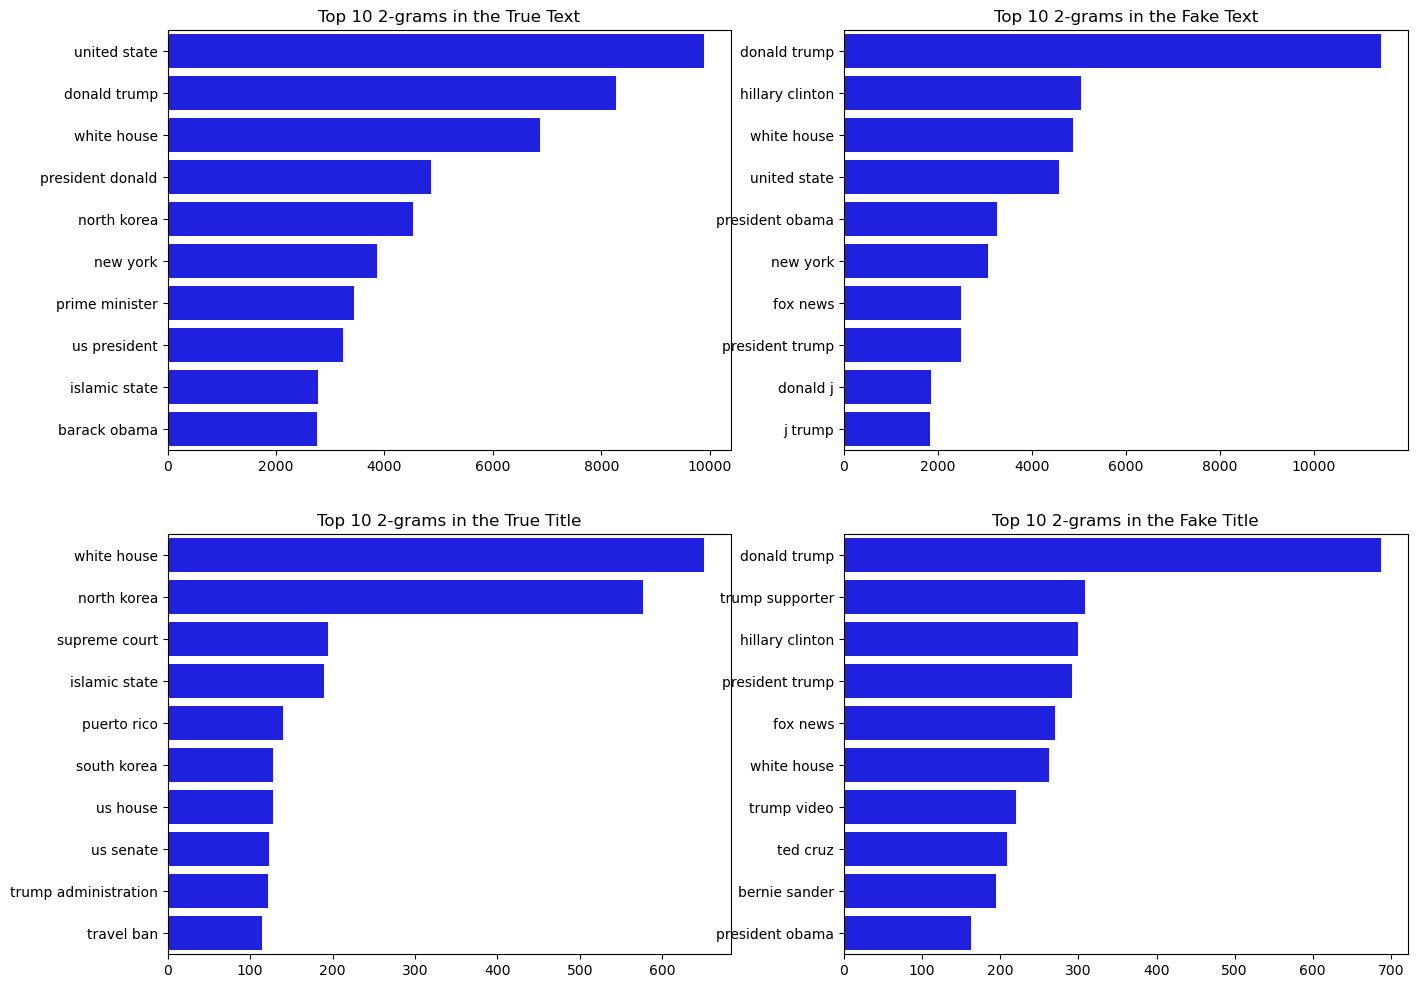

In [24]:
# 2x2 grid to plot text and title per type of article (real ad fake)

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

ax_flat = axes.flatten()

plot_n_grams(final_true["text_tok"], n = 2, txt = "True Text", ax = ax_flat[0])
plot_n_grams(final_false["text_tok"], n = 2, txt = "Fake Text", ax = ax_flat[1])

plot_n_grams(final_true["title_tok"], n = 2, txt = "True Title", ax = ax_flat[2])
plot_n_grams(final_false["title_tok"], n = 2, txt = "Fake Title", ax = ax_flat[3])

This graph shows the most common 2 word combination in the articles. One can observe that most of the common 2 word combinations are mainly names of people, places or identities/ organizations, such as, donald trump, hilary clinton, new york, united states, and us sentate. There seems to be a focus of right wings individuals for the fake titles.

In [25]:
def sentiment(data):
    scores = []
    for txt in data:
        txt_str = str(txt)
        polarity_s = sid.polarity_scores(txt_str)

        scores.append(polarity_s["compound"])
    return scores

In [26]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Marie\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [27]:
sid = SentimentIntensityAnalyzer()

final_true = df_reliable

final_true["sentiment"] = sentiment(final_true["title"])
final_false["sentiment"] = sentiment(final_false["title"])

print(f"Average True Title Sentiment: {round(final_true["sentiment"].mean(), 4)}")
print(f"Average Fake Title Sentiment: {round(final_false["sentiment"].mean(), 4)}")

Average True Title Sentiment: -0.1124
Average Fake Title Sentiment: -0.1595


The results indicate that the titles have negative sentiment (sentiment is measure from [-1 (negative), 1 (positive]). This may relate to how most fake articles and title tend to be negative to instill fear or anger (i.e. clickbait). On the other hand real news which still has a negative sentiment, but not as large in magnitude. This could also be due to the dataset itself which mostly contained political news.

In [28]:
final_true.loc[:, "sentiment"] = sentiment(final_true["text"])
final_false.loc[:, "sentiment"] = sentiment(final_false["text"])

print(f"Average True Text Sentiment: {round(final_true["sentiment"].mean(), 4)}")
print(f"Average Fake Text Sentiment: {round(final_false["sentiment"].mean(), 4)}")

Average True Text Sentiment: -0.0116
Average Fake Text Sentiment: -0.0891


The results indicate that the titles have negative sentiment. The real news has a negative sentiment but it is closer to 0 which could be considered neutral cosidering the scale is from [-1,1].

Graphs Relating Length of the Original (uncleaned) Article

In [29]:
final_true["length_txt"] = final_true["text"].apply(lambda x: len(str(x)))
final_false["length_txt"] = final_false["text"].apply(lambda x: len(str(x)))

Text(0, 0.5, 'Number of Articles')

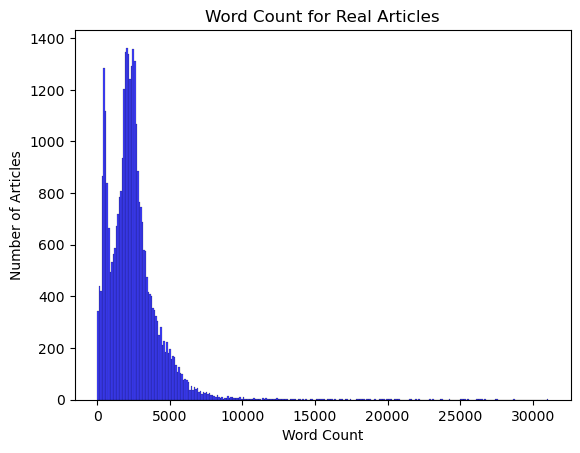

In [30]:
sns.histplot(final_true["length_txt"], color = "blue")
plt.title("Word Count for Real Articles")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")

Text(0, 0.5, 'Number of Articles')

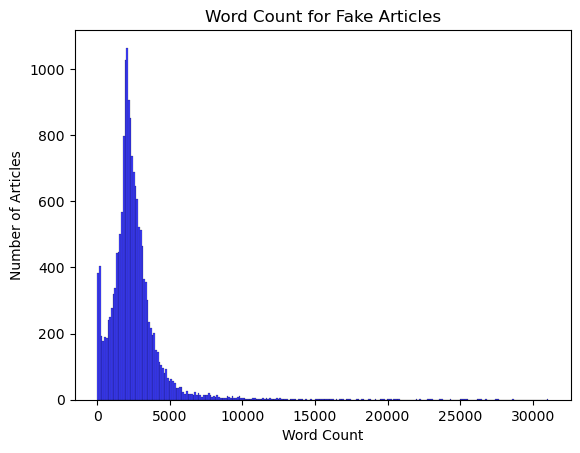

In [31]:
sns.histplot(final_false["length_txt"], color = "blue")
plt.title("Word Count for Fake Articles")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")

This was the main reason why I decided to put a limit to the length of article in terms of words. It can be seen how there for both types of articles they have a few larger text that have a large legnth. However most of the concentration is within the 0 to 5K legnth. Therefore, a limit of 5K words was imposed in the preprocessing.

The interesting thing about this dataset is that we also have access to the subject of the article, hecne we wanted to determine whether certain subject are more prone to fake news or not. Our hypothesis given the previous graphs is that politics may be more present in the dataset hence it will be the subject with most fake news and real news.

In [32]:
df_reliable.columns

Index(['title', 'text', 'subject', 'date', 'label', 'text_clean',
       'title_clean', 'title_tok', 'text_tok', 'sentiment', 'length_txt'],
      dtype='object')

Text(0.5, 1.0, 'Fake articles subject distribution')

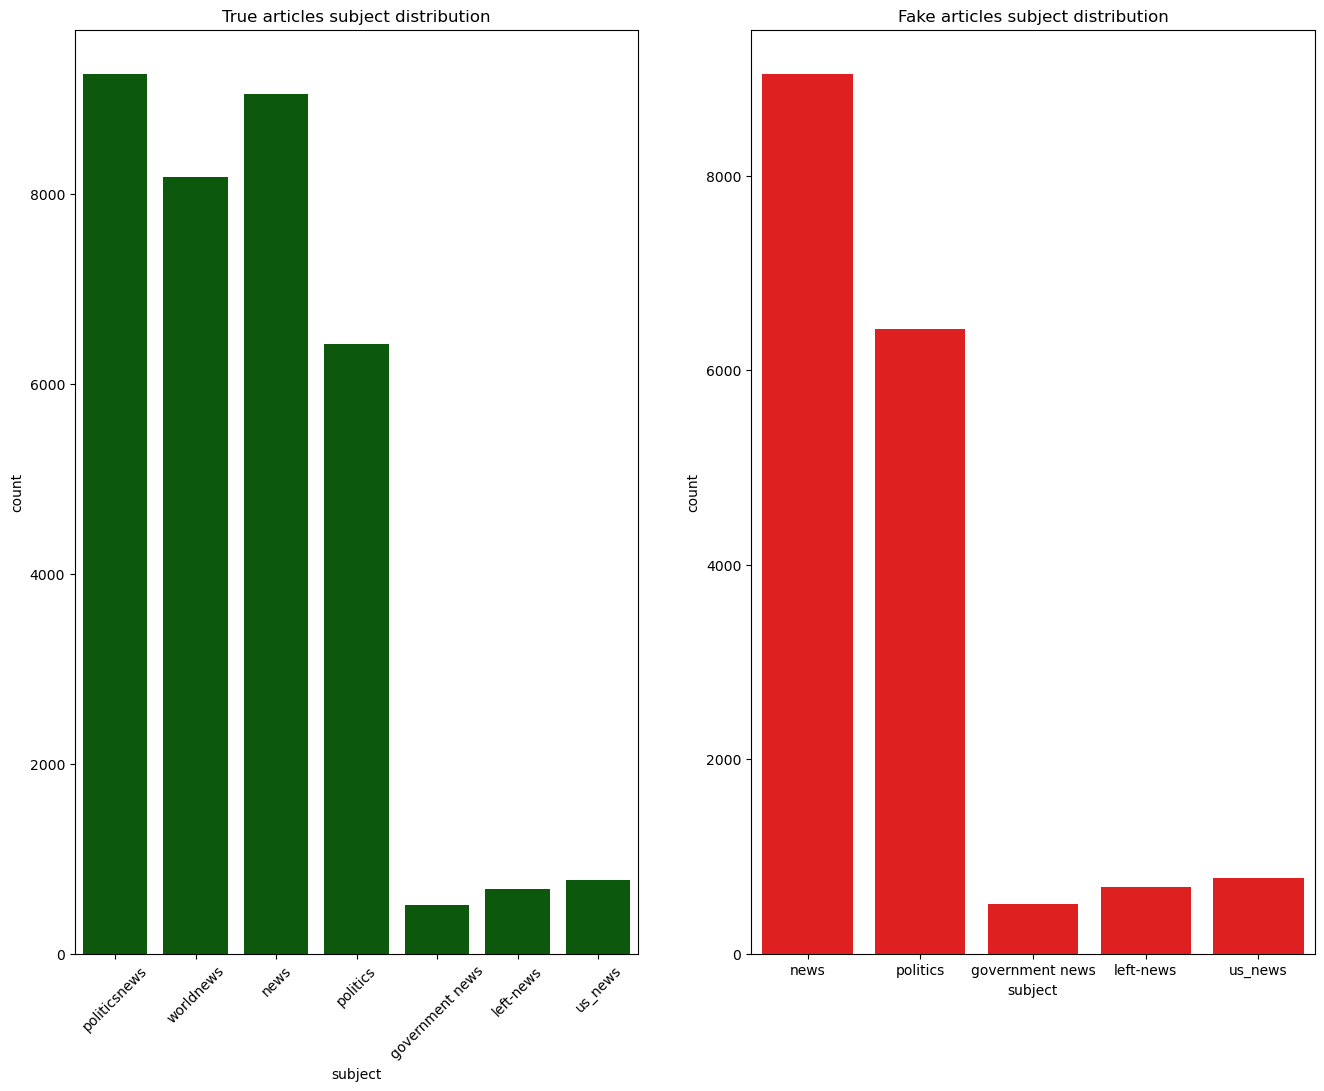

<Figure size 1200x600 with 0 Axes>

In [34]:
# side by side
fig, axes = plt.subplots(1, 2, figsize = (16, 12))

# true news
sns.countplot(
    data = final_true,
    x = "subject",
    ax = axes[0],
    color = "darkgreen")

axes[0].set_title("True articles subject distribution")
axes[0].tick_params(axis = "x", rotation = 45)


# Fake news
plt.figure(figsize = (12, 6))

sns.countplot(
    data = final_false,
    x = "subject",
    ax = axes[1],
    color = "red")
axes[1].set_title("Fake articles subject distribution")




This showcases the most of the dataset is focueses on political news. We looked at the documentation of the dataset and there is not mention of what is meant by news by itself. However, when looking at a few of the headlines one can observe that its general news regarding political figures and other (including sport and econmics).

In [35]:

news_sample = final_true[final_true["subject"] == "worldnews"][["title"]].iloc[1:5]
news_sample

,title
2,mexico senate committees pass controversial se...
6,canada to make fighter jets announcement on de...
12,german would-be partners have very different i...
14,"cubans are heartbroken, angry can't seek u.s. ..."


In [36]:
pd.set_option("display.max_colwidth", None)
news_sample = final_false[final_false["subject"] == "news"][["title"]].iloc[1:5]
news_sample

,title
17443,drunk bragging trump staffer started russian collusion investigation
17444,sheriff david clarke becomes an internet joke for threatening to poke people ‘in the eye’
17445,trump is so obsessed he even has obama’s name coded into his website (images)
17446,pope francis just called out donald trump during his christmas speech


Now in order to investigate where there is clickbait. One can find the average length of the titles. The longer the title the more it can grab someone's attention (i.e. appeaing to emotion).

For example:
- a real article is "German would-be partners have very different immigration ideas"
- clickbait is something like "Trump is so obsessed he even has Obama’s name coded into his website"

In [37]:
final_true["length_tt"] = final_true["title"].apply(lambda x: len(str(x)))
final_false["length_tt"] = final_false["title"].apply(lambda x: len(str(x)))

In [38]:
avg_true_tt = final_true["length_tt"].mean()
avg_false_tt = final_false["length_tt"].mean()

print(f"Average word count for real articles: {avg_true_tt}")
print(f"Average word count for fake articles: {avg_false_tt}")

Average word count for real articles: 77.96754587155964
Average word count for fake articles: 91.22971500659442


Given that we know that there are the same numbers of fake and real articles we conclude that fake articles have longer titles. This could be due to the subjects within the fake articles which may need longer titles as well that its need longer title to try a instigate a reaction.